# Imports

In [1]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA

# USER CONFIGURATION -- CRC_CMS_10x

In [ ]:
# =============================================================================
# USER CONFIGURATION -- CRC_CMS_10x
# =============================================================================

SPACROSS_ROOT = Path(r"/home/dal875013/work/projects/mocha/methods/spacross/SpaCross")

DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/CRC_CMS_10x/data")

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/crc_cms_spacross")

CONFIG_PATH = SPACROSS_ROOT / "Config" / "DLPFC.yaml"

ALL_CRC_CMS_SAMPLES = [
    "SN048_A121573_Rep1",
    "SN048_A121573_Rep2",
    "SN048_A416371_Rep1",
    "SN048_A416371_Rep2",
    "SN123_A551763_Rep1",
    "SN124_A551763_Rep2",
    "SN123_A595688_Rep1",
    "SN124_A595688_Rep2",
    "SN123_A798015_Rep1",
    "SN124_A798015_Rep2",
    "SN123_A938797_Rep1_X",
    "SN124_A938797_Rep2",
    "SN84_A120838_Rep1",
    "SN84_A120838_Rep2",
]

SAMPLES_TO_RUN = "all"

METHOD_NAME = "SpaCross"
CLUST_METHOD = "mclust"
NUM_RUNS = 1

# Fixed spatial domains for CRC_CMS_10x
NUM_CLUSTERS_CRC_CMS = 6

GT_LABEL_COL = "z"
SPATIAL_KEY = "S"


# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available -- using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU -- falling back to CPU")
    return dev


def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w", encoding="utf-8"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


def resolve_samples(selector) -> list:
    if selector is None or selector == "all":
        return list(ALL_CRC_CMS_SAMPLES)
    if isinstance(selector, str):
        return [selector]
    if isinstance(selector, (list, tuple)):
        return [str(s) for s in selector]
    raise ValueError(f"Unrecognized SAMPLES_TO_RUN value: {selector!r}")

# Data loading -- CRC_CMS-specific

In [3]:
# =============================================================================
# Data loading -- CRC_CMS-specific
# =============================================================================
def load_crc_cms_sample(config: dict, sample_id: str, tools_mod):
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")

    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")

    if GT_LABEL_COL not in adata.obs.columns:
        raise KeyError(
            f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
            f"Available: {list(adata.obs.columns)}"
        )

    adata.obs["layer_guess"] = adata.obs[GT_LABEL_COL].astype(object)

    gt_vals = adata.obs["layer_guess"]
    n_labeled = gt_vals.notna().sum()
    uniq_labels = sorted([str(x) for x in gt_vals.dropna().unique()])

    logging.info(
        f"  [DIAG] Using GT column '{GT_LABEL_COL}' "
        f"(labeled: {n_labeled}/{adata.n_obs}, classes: {uniq_labels})"
    )

    if "spatial" not in adata.obsm:
        if SPATIAL_KEY in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm[SPATIAL_KEY])
            logging.info(
                f"  [DIAG] Aliased obsm['{SPATIAL_KEY}'] -> obsm['spatial']"
            )
        else:
            raise KeyError(
                f"No spatial coordinates in {h5ad_path}. "
                f"Available obsm: {list(adata.obsm.keys())}"
            )

    logging.info(f"  [DIAG] spatial coords shape: {adata.obsm['spatial'].shape}")

    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)

    logging.info(f"  [DIAG] Built k-NN graph (k={k})")
    if isinstance(edge_index, torch.Tensor):
        logging.info(f"  [DIAG] graph shape: {tuple(edge_index.shape)}")
        logging.info(f"  [DIAG] graph is_sparse: {edge_index.is_sparse}")

    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()

    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(f"  [DIAG] After gene filter: n_vars={adata.n_vars}")

    sc.pp.normalize_total(adata, target_sum=1e6)

    top_g = min(config["data"]["top_genes"], adata.n_vars)
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=top_g,
    )

    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)

    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata.n_vars} (target={top_g})"
    )

    n_pcs = min(200, adata.n_vars, adata.n_obs - 1)
    adata.obsm["X_pca"] = PCA(
        n_components=n_pcs,
        random_state=42,
    ).fit_transform(adata.X)

    logging.info(f"  [DIAG] PCA done: X_pca shape={adata.obsm['X_pca'].shape}")

    return adata, edge_index

# Training + metrics for one sample

In [4]:
# =============================================================================
# Training + metrics for one sample
# =============================================================================
def train_one_sample(
    sample_id: str,
    adata,
    edge_index,
    config: dict,
    device: str,
    tools_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    num_clusters = NUM_CLUSTERS_CRC_CMS

    logging.info(
        f"  [TRAIN] Starting SpaCross | sample={sample_id} | "
        f"k_clusters={num_clusters} | device={device} | run_seed={run_seed}"
    )

    t0 = time.time()

    net = tools_mod.SC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )

    net.trian()
    enc_rep, recon = net.process()

    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon

    logging.info(
        f"  [DIAG] Latent shape: {enc_rep.shape}  Recon shape: {recon.shape}"
    )

    pred_labels = tools_mod.clustering(
        z=enc_rep,
        n_clust=num_clusters,
        num_seed=1,
        method=clust_method,
    )

    adata.obs[clust_method] = pred_labels

    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0

    sub_adata = adata[~pd.isnull(adata.obs["layer_guess"])]

    ARI, ACC, DIS = tools_mod.get_metrics(
        sub_adata,
        "layer_guess",
        clust_method,
    )

    from SpaCross.Utils import compute_NMI
    NMI = compute_NMI(sub_adata, "layer_guess", clust_method)

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics = {
        "method": METHOD_NAME,
        "dataset": "CRC_CMS_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "ARI": float(ARI),
        "NMI": float(NMI),
        "ACC": float(ACC),
        "DIS": float(DIS),
        "running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "clust_method": clust_method,
        "device": device,
    }

    logging.info(
        f"  [METRICS] ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
        f"DIS={DIS:.4f}  time={elapsed:.1f}s  gpu={gpu_name}"
    )

    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "dataset": "CRC_CMS_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "spot_id": adata.obs_names.astype(str).to_numpy(),
        "true_label": adata.obs["layer_guess"].astype(object).to_numpy(),
        "pred_label": np.asarray(adata.obs[clust_method]).astype(str),
    })

    return metrics, pred_df

# Main benchmark loop

In [5]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("SpaCross CRC_CMS_10x Benchmarking Framework")
    logging.info("=" * 72)

    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(
            f"SPACROSS_ROOT not found: {SPACROSS_ROOT.resolve()}"
        )

    sys.path.insert(0, str(SPACROSS_ROOT.resolve()))
    import SpaCross as TOOLS

    device = get_device()

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
    logging.info(f"[PATHS] CONFIG_PATH   = {CONFIG_PATH.resolve()}")

    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    config["data"]["dataset"] = "CRC_CMS_10x"

    logging.info(f"[CONFIG] {config}")

    samples = resolve_samples(SAMPLES_TO_RUN)

    logging.info(f"[SAMPLES] Will process {len(samples)} sample(s): {samples}")
    logging.info(
        f"[SETTINGS] clust_method={CLUST_METHOD}  "
        f"num_runs={NUM_RUNS}  num_clusters={NUM_CLUSTERS_CRC_CMS}"
    )

    all_metrics = []
    all_predictions = []
    failed = []

    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] Sample {sample_id}")
        logging.info("-" * 72)

        try:
            adata, edge_index = load_crc_cms_sample(config, sample_id, TOOLS)

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")

                adata_run = adata.copy()

                metrics, pred_df = train_one_sample(
                    sample_id=sample_id,
                    adata=adata_run,
                    edge_index=edge_index,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )

                all_metrics.append(metrics)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Sample {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            continue

    if not all_metrics:
        logging.error("No successful runs -- nothing to save.")
        return

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "dataset", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "gpu_model",
    ]

    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    pred_lead = [
        "method", "dataset", "sample", "run_seed",
        "spot_id", "true_label", "pred_label",
    ]

    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"

    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)

    logging.info(
        f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)"
    )
    logging.info(
        f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)"
    )

    logging.info("")
    logging.info("Per-sample metrics:")
    logging.info(
        "\n" + performance[
            ["sample", "ARI", "NMI", "ACC", "DIS", "running_time_sec"]
        ].to_string(index=False)
    )

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )

    if failed:
        logging.warning(f"\n{len(failed)} sample(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['sample']}: {f_['error']}")

    logging.info("\nBenchmarking complete.")


if __name__ == "__main__":
    run_benchmark()

2026-05-11 12:23:06,842 [INFO] Log file: /home/dal875013/work/projects/mocha/results/crc_cms_spacross/benchmark.log
2026-05-11 12:23:06,843 [INFO] ========================================================================
2026-05-11 12:23:06,843 [INFO] SpaCross CRC_CMS_10x Benchmarking Framework
2026-05-11 12:23:06,843 [INFO] ========================================================================
2026-05-11 12:23:10,893 [INFO] cffi mode is CFFI_MODE.ANY
2026-05-11 12:23:11,028 [INFO] R home found: /work/dal875013/conda_envs/spacross_env/lib/R
2026-05-11 12:23:11,976 [INFO] R library path: /work/dal875013/conda_envs/spacross_env/lib:
2026-05-11 12:23:11,977 [INFO] LD_LIBRARY_PATH: /work/dal875013/conda_envs/spacross_env/lib
2026-05-11 12:23:11,992 [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-05-11 12:23:12,530 [INFO] R is already initialized. No need to initialize.
2026-05-11 12:23:14,282 [INFO] [DEVICE] CUDA available -- using cuda:0
2026-05-11 12:23:14,313 [INF

Epoch 299 total loss=1.426 recon loss=0.789 mean loss=0.430 tri loss=1.372: 100%|██████████| 300/300 [00:07<00:00, 40.49it/s]

2026-05-11 12:23:25,138 [INFO]   [DIAG] Latent shape: (2052, 16)  Recon shape: (2052, 200)


[DEBUG mclust] emb shape = (2052, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 12:23:30,365 [INFO]   [DIAG] Cluster sizes: {'1': 699, '2': 348, '3': 318, '4': 317, '6': 288, '5': 82}
2026-05-11 12:23:30,739 [INFO]   [METRICS] ARI=0.2119  NMI=0.3084  ACC=0.3085  DIS=0.0435  time=13.0s  gpu=NVIDIA A30
2026-05-11 12:23:30,743 [INFO] 
2026-05-11 12:23:30,744 [INFO] ------------------------------------------------------------------------
2026-05-11 12:23:30,745 [INFO] [2/14] Sample SN048_A121573_Rep2
2026-05-11 12:23:30,746 [INFO] ------------------------------------------------------------------------
2026-05-11 12:23:30,746 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/CRC_CMS_10x/data/SCE_SN048_A121573_Rep2.h5ad
2026-05-11 12:23:31,265 [INFO]   [DIAG] Loaded AnnData: n_obs=2291, n_vars=36601
2026-05-11 12:23:31,266 [INFO]   [DIAG] obs columns: ['z']
2026-05-11 12:23:31,267 [INFO]   [DIAG] obsm keys  : [

Epoch 299 total loss=1.429 recon loss=0.795 mean loss=0.441 tri loss=1.366: 100%|██████████| 300/300 [00:06<00:00, 45.74it/s]

...

2026-05-11 12:25:32,188 [INFO]   [DIAG] Latent shape: (240, 16)  Recon shape: (240, 200)


[DEBUG mclust] emb shape = (240, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 12:25:32,433 [INFO]   [DIAG] Cluster sizes: {'2': 99, '1': 39, '4': 34, '3': 33, '5': 22, '6': 13}
2026-05-11 12:25:32,453 [INFO]   [METRICS] ARI=0.0431  NMI=0.2034  ACC=0.2035  DIS=0.1333  time=4.6s  gpu=NVIDIA A30
2026-05-11 12:25:32,455 [INFO] 
2026-05-11 12:25:32,456 [INFO] ------------------------------------------------------------------------
2026-05-11 12:25:32,457 [INFO] [14/14] Sample SN84_A120838_Rep2
2026-05-11 12:25:32,457 [INFO] ------------------------------------------------------------------------
2026-05-11 12:25:32,458 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/CRC_CMS_10x/data/SCE_SN84_A120838_Rep2.h5ad
2026-05-11 12:25:32,785 [INFO]   [DIAG] Loaded AnnData: n_obs=853, n_vars=36601
2026-05-11 12:25:32,787 [INFO]   [DIAG] obs columns: ['z']
2026-05-11 12:25:32,787 [INFO]   [DIAG] obsm keys  : ['S']
2026

Epoch 299 total loss=1.516 recon loss=0.944 mean loss=0.430 tri loss=1.367: 100%|██████████| 300/300 [00:05<00:00, 59.98it/s]

2026-05-11 12:25:38,679 [INFO]   [DIAG] Latent shape: (853, 16)  Recon shape: (853, 200)


[DEBUG mclust] emb shape = (853, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 12:25:39,595 [INFO]   [DIAG] Cluster sizes: {'1': 285, '6': 222, '4': 96, '5': 94, '2': 87, '3': 69}
2026-05-11 12:25:39,679 [INFO]   [METRICS] ARI=0.1079  NMI=0.1879  ACC=0.1879  DIS=0.0738  time=5.9s  gpu=NVIDIA A30
2026-05-11 12:25:39,823 [INFO] 
2026-05-11 12:25:39,825 [INFO] ========================================================================
2026-05-11 12:25:39,825 [INFO] SAVED
2026-05-11 12:25:39,826 [INFO] ========================================================================
2026-05-11 12:25:39,826 [INFO]   predictions.parquet -> /home/dal875013/work/projects/mocha/results/crc_cms_spacross/predictions.parquet  (19,492 rows)
2026-05-11 12:25:39,827 [INFO]   performance.parquet -> /home/dal875013/work/projects/mocha/results/crc_cms_spacross/performance.parquet  (14 rows)
2026-05-11 12:25:39,828 [INFO] 
2026-05-11 12:25

# prediction results visualization

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


SAMPLE_ID = SN123_A938797_Rep1_X
n spots in adata      : 1945
n predictions matched : 1945


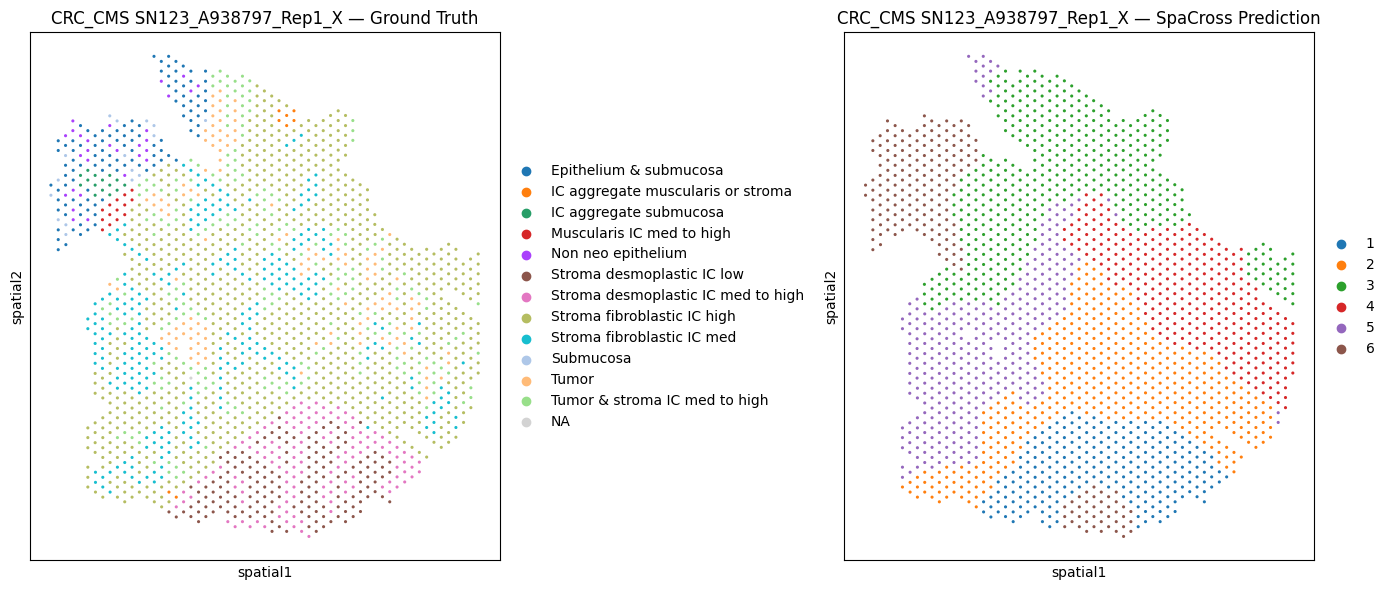

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/CRC_CMS_10x/data")
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/crc_cms_spacross")

SAMPLE_ID = "SN123_A938797_Rep1_X"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

predictions["sample"] = predictions["sample"].astype(str)
pred_slice = predictions[predictions["sample"] == str(SAMPLE_ID)].copy()

if pred_slice.empty:
    available = sorted(predictions["sample"].unique())
    raise ValueError(
        f"No predictions found for sample {SAMPLE_ID}. "
        f"Available samples: {available}"
    )

pred_slice = pred_slice.set_index("spot_id")

adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")
adata.var_names_make_unique()

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

if "spatial" not in adata.obsm:
    if "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
    else:
        raise KeyError(f"No spatial coordinates found. obsm keys = {list(adata.obsm.keys())}")

print(f"SAMPLE_ID = {SAMPLE_ID}")
print(f"n spots in adata      : {adata.n_obs}")
print(f"n predictions matched : {pred_slice.index.isin(adata.obs_names).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="true_label",
    ax=axes[0],
    show=False,
    title=f"CRC_CMS {SAMPLE_ID} — Ground Truth",
    s=20,
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="pred_label",
    ax=axes[1],
    show=False,
    title=f"CRC_CMS {SAMPLE_ID} — SpaCross Prediction",
    s=20,
)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# Running results summary

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/crc_cms_spacross")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)

performance["sample"] = performance["sample"].astype(str)
performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "dataset", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "clust_method", "gpu_model",
]

display_cols = [c for c in display_cols if c in performance.columns]

print("===== All CRC_CMS SpaCross results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary_cols = [c for c in ["ARI", "NMI", "ACC", "DIS", "running_time_sec"] if c in performance.columns]
display(performance[summary_cols].describe())

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All CRC_CMS SpaCross results =====


,dataset,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,clust_method,gpu_model
0,CRC_CMS_10x,SN048_A121573_Rep1,0,0.211864,0.308354,0.308508,0.043541,6,2052,2052,13.01,mclust,NVIDIA A30
1,CRC_CMS_10x,SN048_A121573_Rep2,0,0.251988,0.307178,0.307233,0.048717,6,2291,2291,11.59,mclust,NVIDIA A30
2,CRC_CMS_10x,SN048_A416371_Rep1,0,0.056167,0.114135,0.115180,0.050732,6,2317,2317,11.57,mclust,NVIDIA A30
3,CRC_CMS_10x,SN048_A416371_Rep2,0,0.071021,0.116458,0.117193,0.044849,6,1803,1802,10.24,mclust,NVIDIA A30
4,CRC_CMS_10x,SN123_A551763_Rep1,0,0.013777,0.091145,0.094236,0.072748,6,665,665,5.59,mclust,NVIDIA A30
5,CRC_CMS_10x,SN123_A595688_Rep1,0,0.146083,0.322403,0.324952,0.065140,6,1111,1111,6.29,mclust,NVIDIA A30
6,CRC_CMS_10x,SN123_A798015_Rep1,0,0.163082,0.288948,0.290092,0.054095,6,1635,1609,8.87,mclust,NVIDIA A30
7,CRC_CMS_10x,SN123_A938797_Rep1_X,0,0.132369,0.291650,0.291681,0.050788,6,1945,1944,10.67,mclust,NVIDIA A30
8,CRC_CMS_10x,SN124_A551763_Rep2,0,0.003067,0.025393,0.027631,0.063115,6,1165,1162,6.80,mclust,NVIDIA A30
9,CRC_CMS_10x,SN124_A595688_Rep2,0,0.211020,0.438996,0.439577,0.062260,6,356,356,4.44,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,14.000000,14.000000,14.000000,14.000000,14.000000
mean,0.119528,0.235059,0.236104,0.062892,8.291429
std,0.079380,0.118077,0.117876,0.022353,2.797163
min,0.003067,0.025393,0.027631,0.043541,4.440000
25%,0.059725,0.134317,0.134875,0.050746,6.035000
50%,0.120118,0.256142,0.256714,0.058712,8.250000
75%,0.184484,0.308060,0.308189,0.064634,10.562500
max,0.251988,0.438996,0.439577,0.133292,13.010000



===== Mean metrics =====
Mean ARI: 0.1195
Mean NMI: 0.2351
Mean ACC: 0.2361
Mean DIS: 0.0629

===== Best / worst ARI =====
Best ARI : SN048_A121573_Rep2  ARI=0.2520
Worst ARI: SN124_A551763_Rep2  ARI=0.0031


# actual layer in ground truth checking

In [8]:
import scanpy as sc
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/CRC_CMS_10x/data")

ALL_CRC_CMS_SAMPLES = [
    "SN048_A121573_Rep1",
    "SN048_A121573_Rep2",
    "SN048_A416371_Rep1",
    "SN048_A416371_Rep2",
    "SN123_A551763_Rep1",
    "SN124_A551763_Rep2",
    "SN123_A595688_Rep1",
    "SN124_A595688_Rep2",
    "SN123_A798015_Rep1",
    "SN124_A798015_Rep2",
    "SN123_A938797_Rep1_X",
    "SN124_A938797_Rep2",
    "SN84_A120838_Rep1",
    "SN84_A120838_Rep2",
]

results = []

for sample_id in ALL_CRC_CMS_SAMPLES:
    path = DATA_ROOT / f"SCE_{sample_id}.h5ad"

    if not path.exists():
        print(f"[MISSING] {sample_id}")
        continue

    adata = sc.read_h5ad(path)

    if "z" not in adata.obs:
        print(f"[NO LABEL] {sample_id}")
        continue

    labels_all = adata.obs["z"]

    # remove NaN labels
    labels = labels_all.dropna()

    unique_labels = sorted(labels.unique())
    n_classes = len(unique_labels)

    results.append({
        "sample": sample_id,
        "n_classes": n_classes,
        "labels": unique_labels,
        "n_spots": adata.n_obs,
        "n_labeled": len(labels),
        "n_NA": int(labels_all.isna().sum()),
    })

df = pd.DataFrame(results).sort_values("n_classes")

print("===== CRC_CMS_10x: Per-sample class counts =====")
display(df)

print("\n===== Summary =====")
print(df["n_classes"].value_counts().sort_index())

print("\n===== Samples with only 1 class =====")
print(df[df["n_classes"] == 1]["sample"].tolist())

print("\n===== Suggested dictionary: sample -> n_classes =====")
cluster_dict = dict(zip(df["sample"], df["n_classes"]))
print(cluster_dict)

===== CRC_CMS_10x: Per-sample class counts =====


,sample,n_classes,labels,n_spots,n_labeled,n_NA
3,SN048_A416371_Rep2,4,"[Stroma fibroblastic IC high, Stroma fibroblas...",1803,1802,1
2,SN048_A416371_Rep1,4,"[Stroma fibroblastic IC high, Stroma fibroblas...",2317,2317,0
5,SN124_A551763_Rep2,4,"[Stroma fibroblastic IC high, Stroma fibroblas...",1165,1162,3
4,SN123_A551763_Rep1,4,"[Stroma fibroblastic IC high, Stroma fibroblas...",665,665,0
1,SN048_A121573_Rep2,6,"[Epithelium & submucosa, Non neo epithelium, S...",2291,2291,0
12,SN84_A120838_Rep1,6,"[Stroma fibroblastic IC high, Stroma fibroblas...",240,240,0
13,SN84_A120838_Rep2,7,"[IC aggregate muscularis or stroma, Stroma fib...",853,853,0
0,SN048_A121573_Rep1,7,"[Epithelium & submucosa, IC aggregate submucos...",2052,2052,0
7,SN124_A595688_Rep2,8,"[Epithelium & submucosa, IC aggregate muscular...",356,356,0
6,SN123_A595688_Rep1,10,"[Epithelium & submucosa, IC aggregate muscular...",1111,1111,0



===== Summary =====
n_classes
4     4
6     2
7     2
8     1
10    1
11    2
12    2
Name: count, dtype: int64

===== Samples with only 1 class =====
[]

===== Suggested dictionary: sample -> n_classes =====
{'SN048_A416371_Rep2': 4, 'SN048_A416371_Rep1': 4, 'SN124_A551763_Rep2': 4, 'SN123_A551763_Rep1': 4, 'SN048_A121573_Rep2': 6, 'SN84_A120838_Rep1': 6, 'SN84_A120838_Rep2': 7, 'SN048_A121573_Rep1': 7, 'SN124_A595688_Rep2': 8, 'SN123_A595688_Rep1': 10, 'SN123_A798015_Rep1': 11, 'SN124_A798015_Rep2': 11, 'SN124_A938797_Rep2': 12, 'SN123_A938797_Rep1_X': 12}
